测试分布随机性

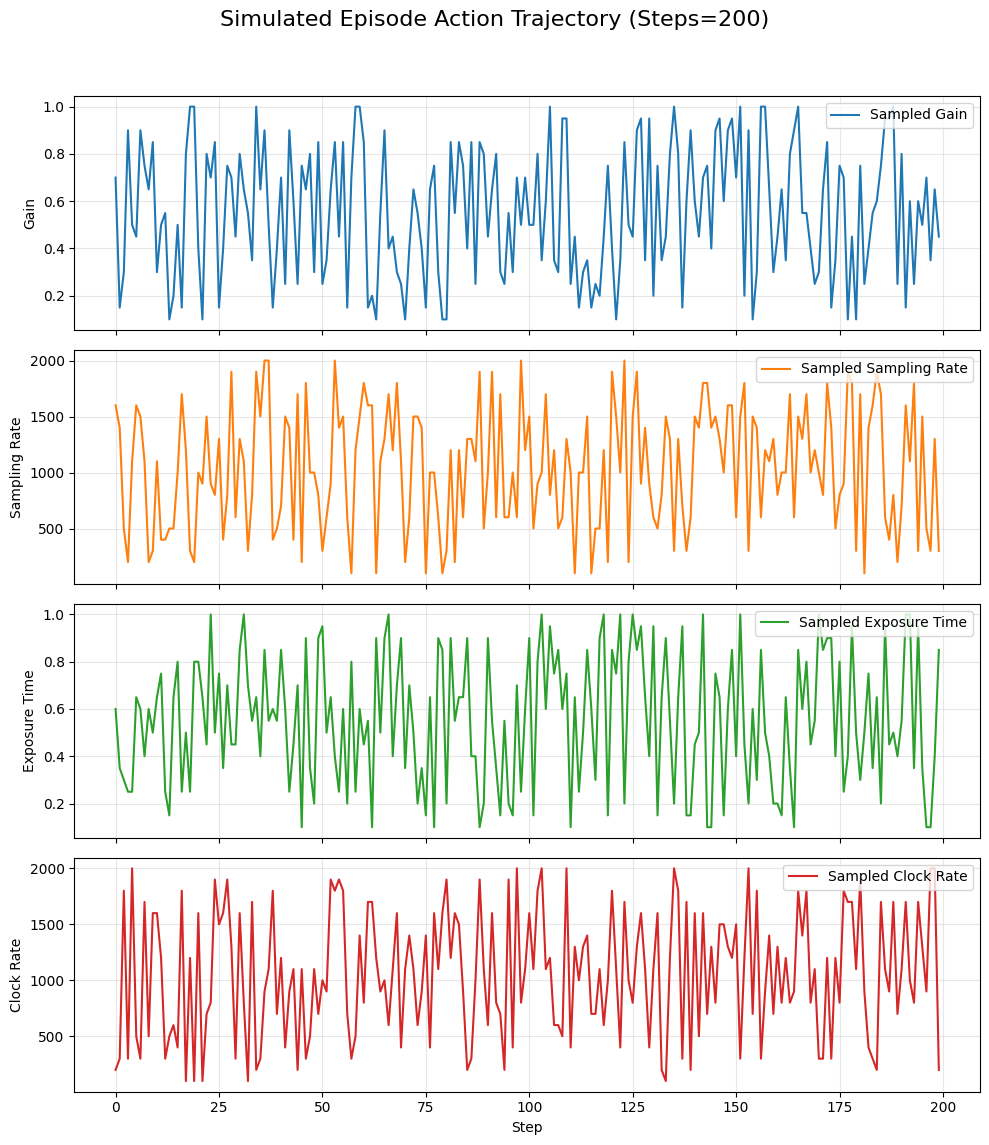

In [ ]:
# 测试：可以随机采样
import torch
import torch.nn.functional as F
import numpy as np
from tools import MultiOneHotDist
import matplotlib.pyplot as plt

# --- 1. 定义你的环境参数 ---
class CameraEnvParams:
    def __init__(self):
        self.gain_dim = 19
        self.sampling_rate_dim = 20
        self.exposure_time_dim = 19
        self.clock_rate_dim = 20
        self.nvec = [self.gain_dim, self.sampling_rate_dim, self.exposure_time_dim, self.clock_rate_dim]
        
        # 物理值映射
        self.gain_values = np.round(np.linspace(0.1, 1.0, self.gain_dim), 2)
        self.sampling_rate_values = np.arange(100, 2100, 100)
        self.exposure_time_values = np.round(np.linspace(0.1, 1.0, self.exposure_time_dim), 2)
        self.clock_rate_values = np.arange(100, 2100, 100)
        self.all_values = [self.gain_values, self.sampling_rate_values, 
                           self.exposure_time_values, self.clock_rate_values]

# --- 2. 模拟采样过程 ---
def simulate_episode(steps=200, unimix=0.01):
    params = CameraEnvParams()
    total_logits_dim = sum(params.nvec)
    
    # 模拟网络输出：加入一点随机扰动模拟未训练的网络
    # 注意：如果这里 std 很大，动作就会变固定
    raw_logits = torch.randn(steps, total_logits_dim) * 0.5 
    
    # 存储转换后的物理值
    history = { "gain": [], "sampling_rate": [], "exposure_time": [], "clock_rate": [] }
    keys = list(history.keys())

    for t in range(steps):
        # 实例化你的分布
        dist = MultiOneHotDist(raw_logits[t:t+1], params.nvec, unimix_ratio=unimix)
        action_onehot = dist.sample().squeeze(0) # [78]
        
        # 将 one-hot 转回物理值
        pointer = 0
        for i, dim in enumerate(params.nvec):
            # 获取当前维度的 one-hot 部分并找到索引
            sub_action = action_onehot[pointer : pointer + dim]
            idx = torch.argmax(sub_action).item()
            
            # 映射到物理值
            val = params.all_values[i][idx]
            history[keys[i]].append(val)
            pointer += dim
            
    return history

# --- 3. 绘图 ---
def plot_actions(history):
    steps = len(history['gain'])
    fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
    titles = ['Gain', 'Sampling Rate', 'Exposure Time', 'Clock Rate']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, key in enumerate(history.keys()):
        axs[i].plot(range(steps), history[key], color=colors[i], label=f'Sampled {titles[i]}')
        axs[i].set_ylabel(titles[i])
        axs[i].grid(True, alpha=0.3)
        axs[i].legend(loc='upper right')
        
    plt.xlabel('Step')
    plt.suptitle(f'Simulated Episode Action Trajectory (Steps={steps})', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 执行
# 注意：运行前请确保你之前定义的 OneHotDist 和 MultiOneHotDist 已在上下文中
history_data = simulate_episode(steps=200)
plot_actions(history_data)

--- 开始测试 random_agent 动作分布 (采样步数: 200) ---
维度 0 (Gain Index): 激活了 19/19 个不同索引
维度 1 (Sampling Rate Index): 激活了 20/20 个不同索引
维度 2 (Exposure Index): 激活了 19/19 个不同索引
维度 3 (Clock Rate Index): 激活了 20/20 个不同索引


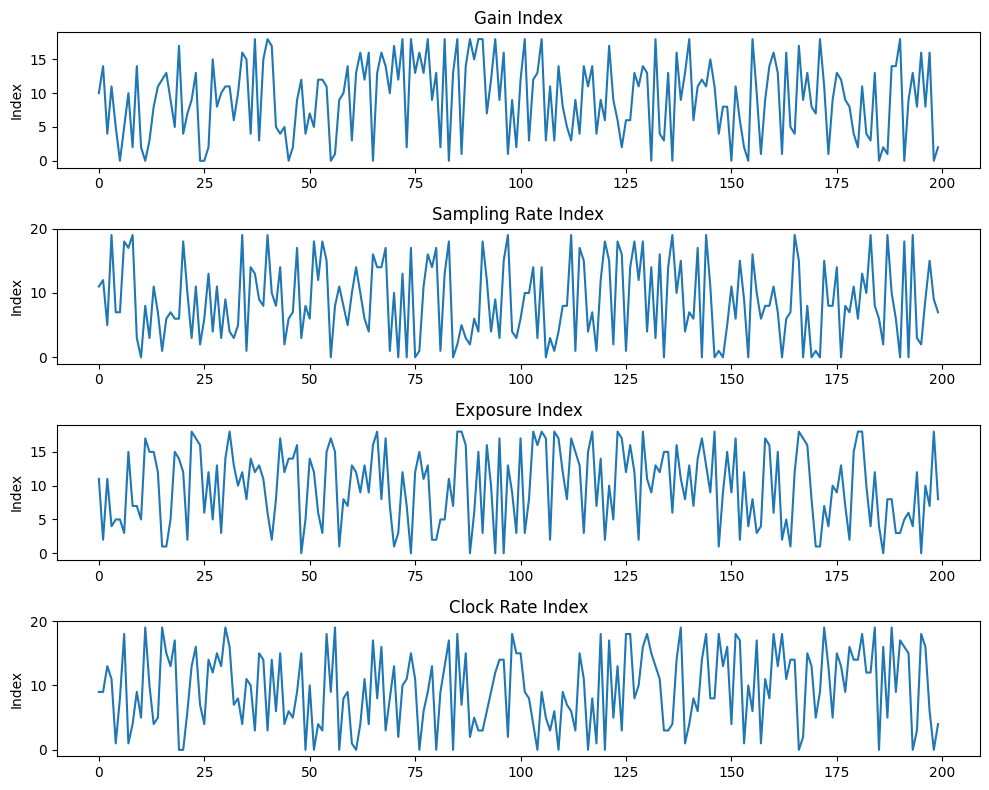

In [7]:
def test_random_agent_distribution(nvec=[19, 20, 19, 20], steps=200):
    print(f"--- 开始测试 random_agent 动作分布 (采样步数: {steps}) ---")
    
    # 1. 模拟 Dreamer 中的 random_actor 设置
    # 在 profile 阶段，logits 通常被初始化为全 0
    total_dim = sum(nvec)
    logits = torch.zeros(1, total_dim) # 假设 config.envs = 1
    
    # 这里使用你定义的 MultiOneHotDist
    # 建议带上 unimix_ratio 进行测试
    random_actor = MultiOneHotDist(logits, nvec, unimix_ratio=0)

    # 2. 定义 random_agent (保持和你代码一致)
    def random_agent(o, d, s):
        action = random_actor.sample()
        logprob = random_actor.log_prob(action)
        return {"action": action, "logprob": logprob}, None

    # 3. 模拟采样
    history_indices = [[] for _ in range(len(nvec))]
    
    for _ in range(steps):
        # 模拟输入 (obs, done, state)
        output, _ = random_agent(None, None, None)
        action_vec = output["action"].squeeze(0).cpu().numpy()
        
        # 解码 one-hot 拼接向量
        pointer = 0
        for i, dim in enumerate(nvec):
            sub_action = action_vec[pointer : pointer + dim]
            idx = np.argmax(sub_action)
            history_indices[i].append(idx)
            pointer += dim

    # 4. 可视化结果
    fig, axes = plt.subplots(len(nvec), 1, figsize=(10, 8))
    titles = ['Gain Index', 'Sampling Rate Index', 'Exposure Index', 'Clock Rate Index']
    
    for i in range(len(nvec)):
        axes[i].plot(history_indices[i], label=f'Dim {i}')
        axes[i].set_ylabel('Index')
        axes[i].set_title(titles[i])
        axes[i].set_ylim(-1, nvec[i])
        
        # 计算激活率
        unique_count = len(np.unique(history_indices[i]))
        print(f"维度 {i} ({titles[i]}): 激活了 {unique_count}/{nvec[i]} 个不同索引")

    plt.tight_layout()
    plt.show()

# 执行测试
if __name__ == "__main__":
    # 确保 MultiOneHotDist 类已在上下文中定义
    test_random_agent_distribution()